# FITTING NOTEBOOK - NIRSpec

In [1]:
# ALWAYS RUN THE FIRST THREE CELLS
import juliet
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
import corner
# import transitspectroscopy as ts
from tqdm import tqdm
import pandas as pd
import csv

import seaborn as sns
sns.set_style('ticks')

In [2]:
# Open data file (transitspectroscopy output)
path = '/media/peng/KINGSTON/'
with open(path + '_jw03385002001_toi1130_nrs1_spectrum.pkl', 'rb') as file:
    data = pickle.load(file)

# NIRSpec
# data is a dict with 7 entries: 
# 1. metadata: Information about instrument and detector, ex. name: NIRSpec, detector: NRS1
# 2. & 3. tso & tso_err: Not sure, just a bunch of zeroes as far as I can see
# 4. traces: Contains times in random order, x, ycorrected, ysmoothed
# 5 spectra: Contains times in increasing order, original + original_err, corrected + corrected_err, wavelength map (a bunch of nans) and wavelengths that the detector measures
# --> IMPORTANT: data['spectra']['corrected'] and corrected_err contain each spectroscopic lc for the corresponding wavelength in ppm (more detail in next section)
# 6 & 7. whitelight & whitelight_err: Relative flux for white light curve and its errorbars

In [3]:
# Define planetary parameters
per = 4.074554             # Period (Days)
t0 = 2460543.0635          # Mid-Transit Time (BJD)
a = 13.77                  # Semimajor Axis (a/R*)
b = -0.518                 # Impact Parameter
ecc = 0.052162             # Eccentricity
omega = 141.11             # Argument of Periastron (Degrees)

# Define planet and instrument name
star = 'TOI-1130'
pn = 'TOI-1130b'
itm = 'NRS1'

# White Light Curves

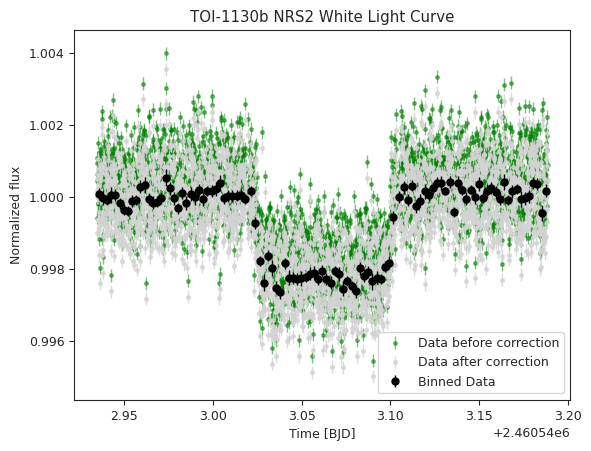

In [16]:
# Define time and flux data points - white light curves
t = data['spectra']['times']
f_wl = data['whitelight']
ferr_wl = data['whitelight_err']

plt.errorbar(t, f_wl, yerr = ferr_wl, fmt = '.', color = 'g', ms = 5, elinewidth = 1, alpha = 0.5, label = 'Data before correction', zorder = 1)

# Normalize flux such that the out-of-transit flux = 1
f_med = np.nanmedian(f_wl[:100])
f_wl, ferr_wl = f_wl / f_med, ferr_wl / f_med
tbin, fbin, ferrbin = juliet.bin_data(t, f_wl, 25)

plt.errorbar(t, f_wl, yerr = ferr_wl, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, alpha = 0.8, label = 'Data after correction', zorder = 5)
plt.errorbar(tbin, fbin, yerr = ferrbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned Data', zorder = 10)

plt.title(pn+' '+itm+ ' White Light Curve')
plt.xlabel('Time [BJD]')
plt.ylabel('Normalized flux')

# # Define root-mean-squared values
# rms = ts.utils.get_mad_sigma(np.median(f_wl[: 100] - 1.), f_wl[: 100] - 1.) * 1e6
# rms_predicted = np.median(ferr_wl[: 100]) * 1e6

plt.legend()
plt.show()

In [17]:
# Define standardized regressors for linear and/or GP fits
def standardized_regressors(x):
    return (x - np.mean(x)) / np.sqrt(np.var(x))

regressors = np.zeros([len(t), 1])   # Array with len(t) rows and 1 column
regressors[:, 0] = standardized_regressors(t)

In [18]:
# Define parameters - comment out all sets except for one

# # Just transit
# params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_'+itm, 'u2_'+itm, 'ecc_p1', 'omega_p1', 'p_p1',
#           'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm]

# dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
#          'fixed', 'normal', 'loguniform']

# hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.]]
# #--------------------------------------------------------------------------------------------------

# Linear
params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_'+itm, 'u2_'+itm, 'ecc_p1', 'omega_p1', 'p_p1',
          'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
          'theta0_'+itm]

dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
         'fixed', 'normal', 'loguniform',
         'uniform']

hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
           1.0, [0., 0.1], [10., 1000.], 
          [-10, 10]]
# #--------------------------------------------------------------------------------------------------

# # GP
# params =  ['P_p1', 't0_p1','a_p1','b_p1', 'u1_'+itm, 'u2_'+itm ,'ecc_p1','omega_p1', 'p_p1',
#            'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
#            'GP_sigma_'+itm, 'GP_rho_'+itm]

# dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
#          'fixed', 'normal', 'loguniform',
#          'loguniform', 'loguniform']

# hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.], 
#            [1e-8, 1e2], [1e-8, 1e3]]
#--------------------------------------------------------------------------------------------------

# Linear + GP
# params =  ['P_p1', 't0_p1','a_p1','b_p1', 'u1_'+itm, 'u2_'+itm ,'ecc_p1','omega_p1', 'p_p1',
#            'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
#            'theta0_'+itm, 'GP_sigma_'+itm, 'GP_rho_'+itm]

# dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
#          'fixed', 'normal', 'loguniform',
#          'uniform', 'loguniform', 'loguniform']

# hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.], 
#            [-10, 10], [1e-6, 1e6], [1e-3, 1e3]]


priors = juliet.generate_priors(params, dists, hyperps) 

In [19]:
# Put data into dictionaries to feed into juliet
times, fluxes, fluxes_err, linear_regressors, GP_regressors = {}, {}, {}, {}, {}
times[itm], fluxes[itm], fluxes_err[itm] = t, f_wl, ferr_wl
linear_regressors[itm] = regressors
GP_regressors[itm] = regressors

# Load dataset and run sampler, again comment out everything except for the one you're running

# # Just transit
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit')
# #---------------------------------------------------------------------------------------------

# Linear
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
                 linear_regressors_lc = linear_regressors,
                 ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit_linear')
# #---------------------------------------------------------------------------------------------

# # GP
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  GP_regressors_lc = GP_regressors,
#                  ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit_GP')
#---------------------------------------------------------------------------------------------

# # Linear + GP
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  linear_regressors_lc = linear_regressors, GP_regressors_lc = GP_regressors,
#                  ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit_linear+GP')

results = dataset.fit(sampler = 'dynamic_dynesty', nthreads = 3, verbose = True, n_live_points = 1000)
print('done')

Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_NRS2_wlcfit_linear/_dynesty_DNS_posteriors.pkl
done


In [20]:
# Take jitter values from posterior and multiply into errors
sigma = np.median(results.posteriors['posterior_samples']['sigma_w_'+itm] * 1e-6)
mflux = np.median(results.posteriors['posterior_samples']['mflux_'+itm])
total_errors = np.sqrt(sigma**2 + ferr_wl**2)

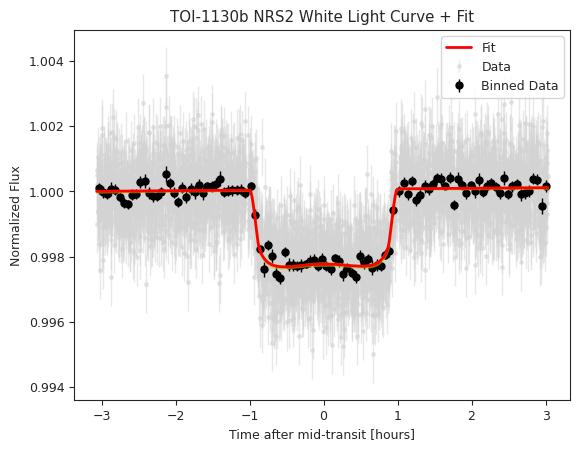

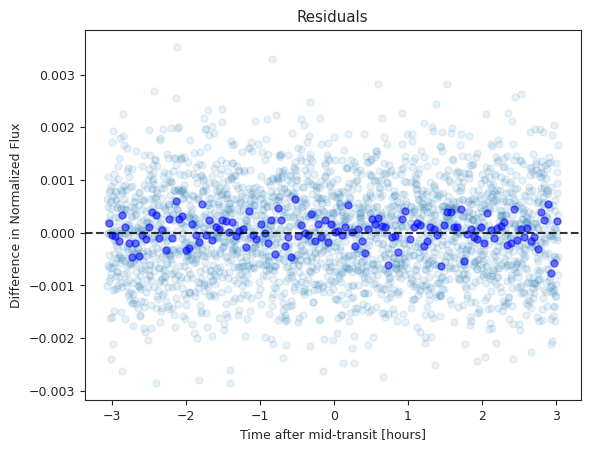

In [21]:
# Normalize time so that it's relative to best-fit mid-transit and make some plots
mid_t = np.nanmedian(results.posteriors['posterior_samples']['t0_p1'])
norm_t = (t - mid_t) * 24
norm_tbin = (tbin - mid_t) * 24

# Scatter data
plt.errorbar(norm_t, f_wl, yerr = total_errors, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, label = 'Data', alpha = 0.5, zorder = 1)
plt.errorbar(norm_tbin, fbin, yerr = ferrbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned Data', zorder = 5)

# Get best fit and +/- 1 sigma band from posterior, then plot
transit_model, transit_up68, transit_low68 = results.lc.evaluate(itm, return_err = True)

plt.plot(norm_t, transit_model, color = 'r', lw = 2, label = 'Fit', zorder = 10)
plt.fill_between(norm_t, transit_up68, transit_low68, color = 'y', alpha = 0.5, zorder = 8)

plt.title(pn+' '+itm+ ' White Light Curve + Fit')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Normalized Flux')
plt.legend()
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+itm+'_wlcfit_linear/'+itm+'_lc_fit.png')
plt.show()

# Residuals plot
resid = f_wl - transit_model
resid_binx, resid_biny, _ = juliet.bin_data(norm_t, resid, 20)

plt.scatter(norm_t, resid, alpha = 0.1, zorder = 1)
plt.scatter(resid_binx, resid_biny, alpha = 0.5, color = 'b', zorder = 5)
plt.axhline(y = 0, ls = '--', color = 'k', alpha = 0.8, zorder = 10)

plt.title('Residuals')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Difference in Normalized Flux')
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+itm+'_wlcfit_linear/'+itm+'_residuals.png')
plt.show()

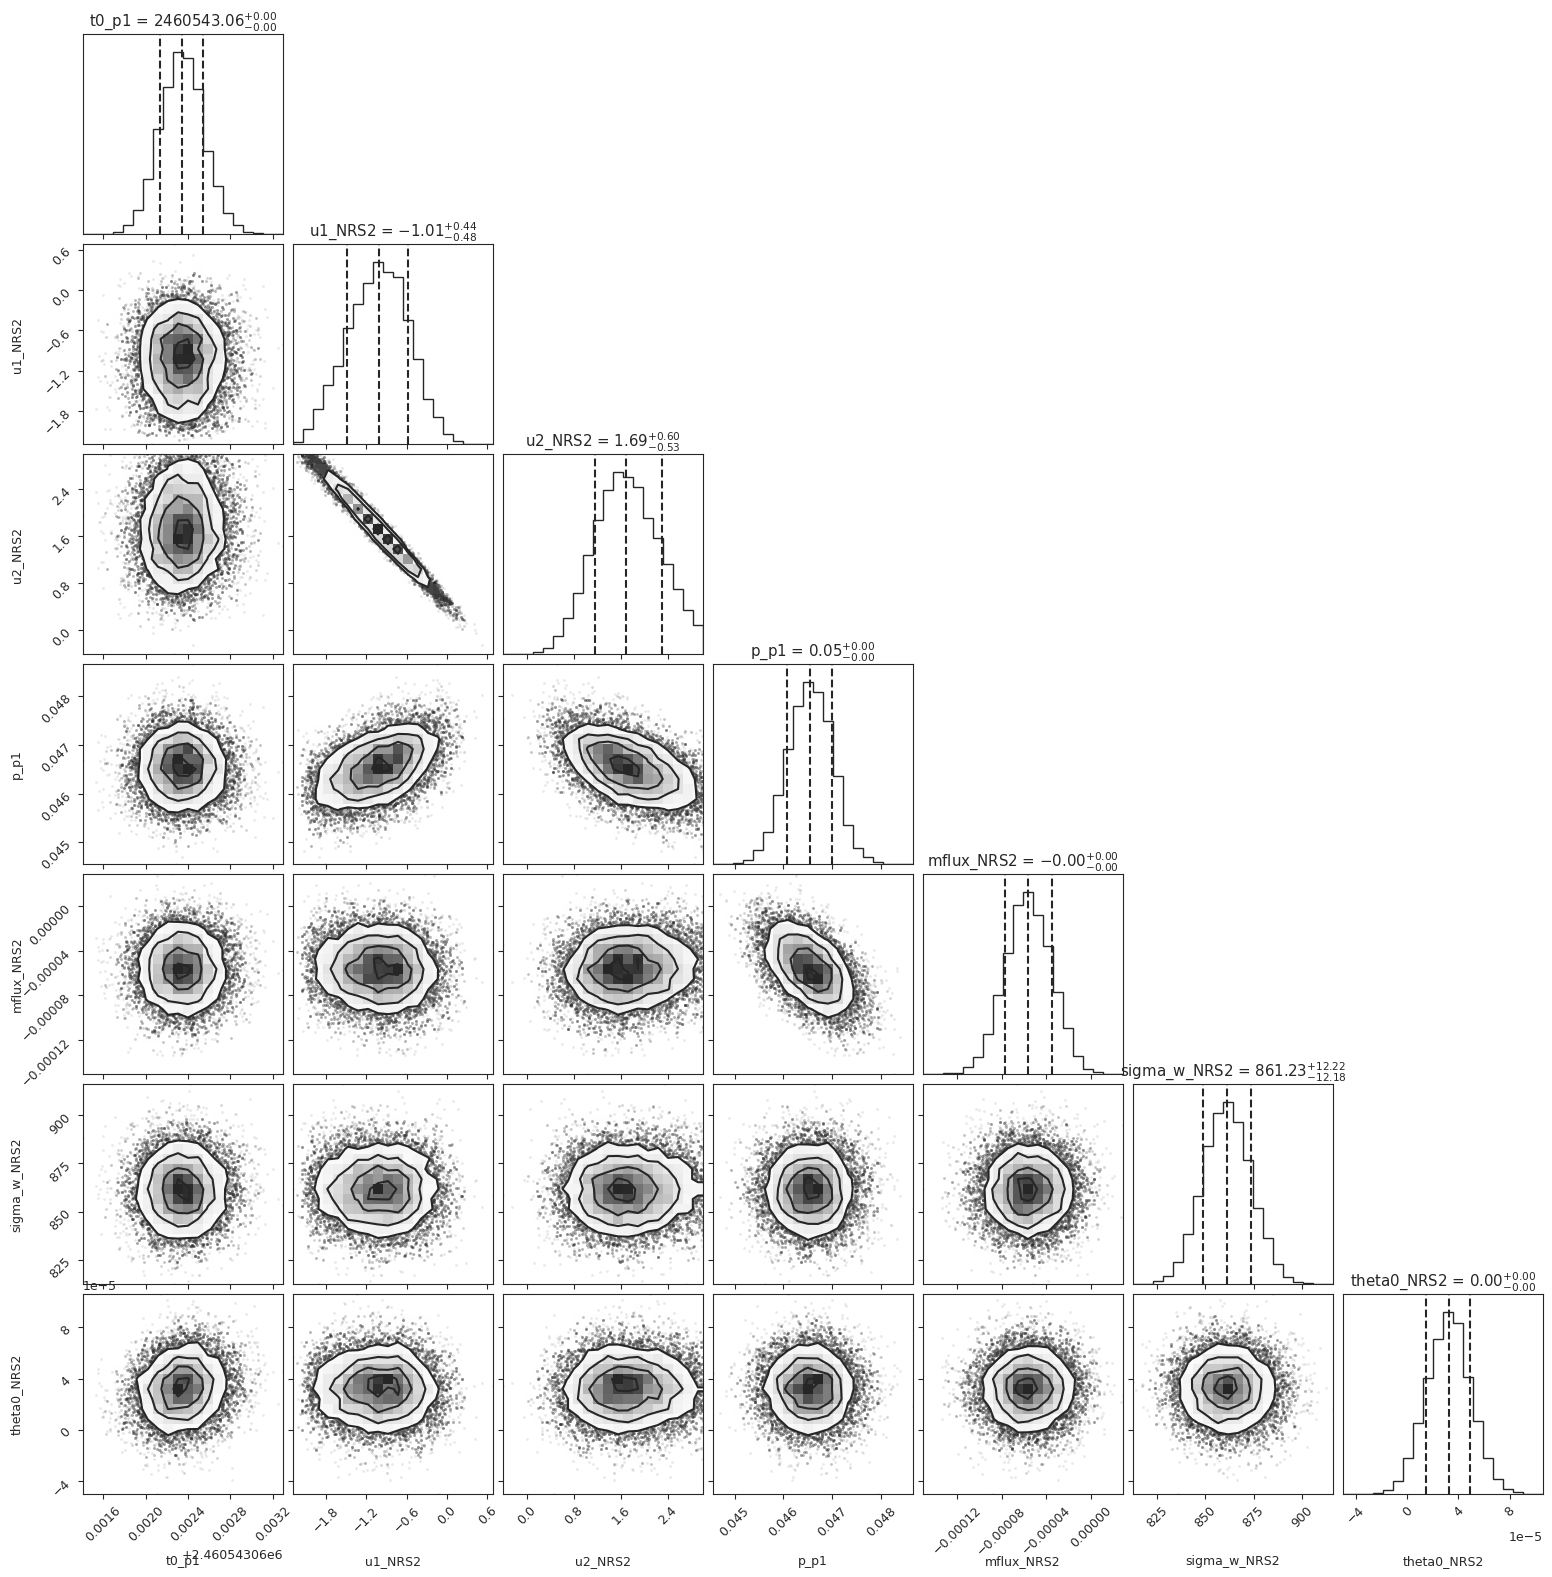

In [22]:
# Corner plot
list_post = []
names = []
for f in results.posteriors['posterior_samples']:
    if f not in ['unnamed', 'loglike']:
        names.append(f)
        list_post.append(results.posteriors['posterior_samples'][f])
tr = np.array(list_post).T
corner.corner(tr, labels = names, show_titles = True, quantiles = [0.16, 0.50, 0.84])
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+itm+'_wlcfit_linear/'+itm+'_corner.png')
plt.show()

In [23]:
# Print log evidence, lnZ
# print('Without linear or GP:', results.posteriors['lnZ'])
print('With linear only:', results.posteriors['lnZ'])
# print('With GP only:', results.posteriors['lnZ'])
# print('With linear + GP:', results.posteriors['lnZ'])

With linear only: 14972.623838445552


In [24]:
# Get transit depth for white light curve
td_list = (results.posteriors['posterior_samples']['p_p1']**2) * 100

td = np.nanmedian(td_list)
tderr = np.sqrt(np.var(td_list))

print('Transit Depth:', td, '\n', 
      'Errors:', tderr)

Transit Depth: 0.2166471182659463 
 Errors: 0.004233196717110537


# Spectroscopic Light Curves

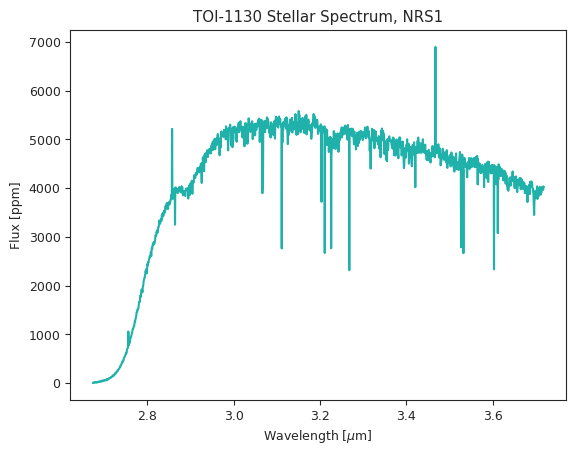

In [5]:
spectra = data['spectra']

# There are m times and n wavelengths
t = spectra['times']
wl = spectra['wavelengths']   

# Each spectra['corrected'] is a mxn array, where columns contain the corresponding spectroscopic light curve in ppm
slc, slcerr = spectra['corrected'], spectra['corrected_err']  

# We can plot corrected spectrum vs wavelength to see something that looks like the stellar spectrum
plt.plot(wl, slc[0], color = 'lightseagreen')
plt.title(star+' Stellar Spectrum, '+itm)
plt.xlabel('Wavelength [$\mu$m]')
plt.ylabel('Flux [ppm]')
plt.show()

# To format slc and slcerr to give fluxes at each wavelength, index them along a column
# For example f[i] = slc[:, i] gives the ith spectroscopic light curve corresponding to the ith wavelength

In [6]:
# Store all spectroscopic light curves in a dict, where each key is a wavelength whose value is another dict. In the nested dict, keys will be flux and flux error 
# --> spec_lcs = {wavelength 1: {flux: [...], err: [...]}, wavelength 2: {flux: [...], err: [...]}, ..., wavelength n: {flux: [...], err: [...]}}
spec_lcs = {}
for i in range(len(wl)):
    wavelength = wl[i]

    # Normalize each light curve 
    slc_med = np.nanmedian(slc[:, i][:100])
    spec_lcs[wavelength] = {}
    spec_lcs[wavelength]['f'] = slc[:, i] / slc_med
    spec_lcs[wavelength]['ferr'] = slcerr[:, i] / slc_med

# for i in spec_lcs:
#     print(i)

In [10]:
# Bin light curves since spec_lcs has spectroscopic light curves in instrument's native resolution
bin_slc = {}
bin_size = 10
for i in range(0, len(wl) - bin_size, bin_size):
    wl_mean = np.round(np.mean(wl[i: i+bin_size]), 7)  # This is just to name the bin
    
    bin_slc[wl_mean] = {}
    bin_slc[wl_mean]['f'] = 0
    bin_slc[wl_mean]['ferr'] = 0

    # Add every 10 spectroscopic light curves together, then normalize flux to 1
    for j in wl[i: i+bin_size]:
        bin_slc[wl_mean]['f'] += spec_lcs[j]['f']
        bin_slc[wl_mean]['ferr'] += spec_lcs[j]['ferr']

    fbin_med = np.nanmedian(bin_slc[wl_mean]['f'][:100])
    bin_slc[wl_mean]['f'] = bin_slc[wl_mean]['f'] / fbin_med
    bin_slc[wl_mean]['ferr'] = bin_slc[wl_mean]['ferr'] / fbin_med

# Run this to see all binned wavelengths
# for i in bin_slc:
#     print(i)

In [12]:
# Define standardized regressors for linear and/or GP fits
def standardized_regressors(x):
    return (x - np.mean(x)) / np.sqrt(np.var(x))

regressors = np.zeros([len(t), 1])   # Array with len(t) rows and 1 column
regressors[:, 0] = standardized_regressors(t)

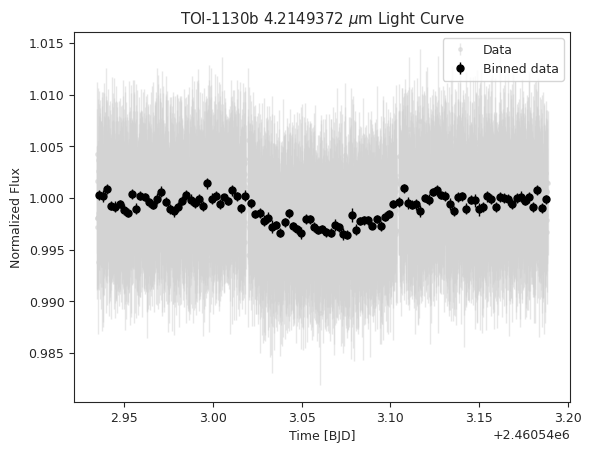

In [13]:
# Define time and flux data points - spectroscopic light curves

trial_list = [3.8534895, 3.9474171, 4.0612377, 4.2149372, 4.4014793, 4.4745839, 4.6204934, 4.8121505, 4.9569554, 5.1012321]

trial_wl = trial_list[3]
t = t     # Sorry I just feel like defining time again for the billionth time

# Uncomment to use native resolution
# f_s = spec_lcs[trial_wl]['f']
# ferr_s = spec_lcs[trial_wl]['ferr']

# Uncomment to use bin_slc
f_s = bin_slc[trial_wl]['f']
ferr_s = bin_slc[trial_wl]['ferr']

# Don't need to normalize since it's already normalized in the dict, so just bin
tbin, fsbin, ferrsbin = juliet.bin_data(t, f_s, 25)

plt.errorbar(t, f_s, yerr = ferr_s, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, alpha = 0.5, label = 'Data', zorder = 1)
plt.errorbar(tbin, fsbin, yerr = ferrsbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned data', zorder = 10)
plt.title(pn+' '+str(round(trial_wl, 7))+' $\mu$m Light Curve')
plt.xlabel('Time [BJD]')
plt.ylabel('Normalized Flux')
plt.legend()

plt.show()

In [14]:
# For now, only define parameters + linear model for NRS1 and 2
# t0 = 2460543.0631091068 # for NRS1
t0 = 2460543.0623039217 # for NRS2

u1 = -1.0117974286 # for NRS2
u2 = 1.6939836238


params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_'+itm, 'u2_'+itm, 'ecc_p1', 'omega_p1', 'p_p1',
          'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
          'theta0_'+itm]

dists = ['fixed', 'fixed', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
         'fixed', 'normal', 'loguniform',
         'uniform']

hyperps = [per, t0, a, b, [-3, 3], [-3, 3], ecc, omega, [0., 0.2],
           1.0, [0., 0.1], [10., 1000.], 
          [-10, 10]]

priors = juliet.generate_priors(params, dists, hyperps)

# Put data into dictionaries
times, fluxes, fluxes_err, linear_regressors, GP_regressors = {}, {}, {}, {}, {}
times[itm], fluxes[itm], fluxes_err[itm] = t, f_s, ferr_s
linear_regressors[itm] = regressors
GP_regressors[itm] = regressors

# Load dataset and run sampler
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
                 linear_regressors_lc = linear_regressors,
                 ld_laws = 'quadratic', out_folder = pn+'_'+str(round(trial_wl, 7))+'_fit')

results = dataset.fit(sampler = 'dynamic_dynesty', nthreads = 3, verbose = True, n_live_points = 1000)
print('done')

Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_4.2149372_fit/_dynesty_DNS_posteriors.pkl
done


In [11]:
# Take jitter values from posterior and multiply into errors
sigma = np.median(results.posteriors['posterior_samples']['sigma_w_'+itm] * 1e-6)
mflux = np.median(results.posteriors['posterior_samples']['mflux_'+itm])
total_errors = np.sqrt(sigma**2 + ferr_s**2)

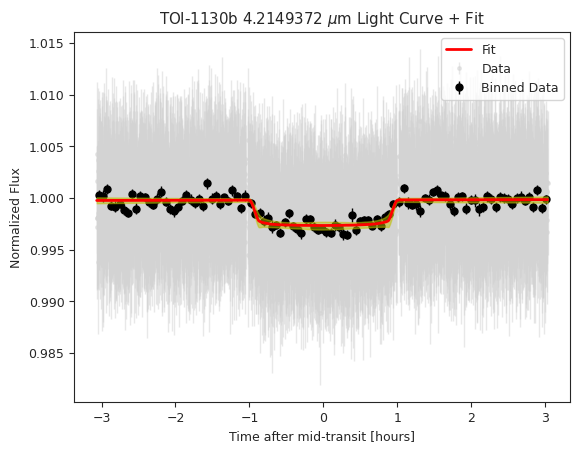

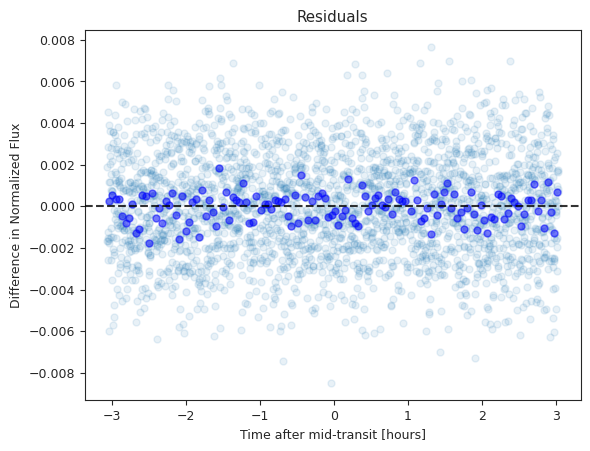

In [13]:
# Normalize time so it's relative to mid-transit
norm_t = (t - t0) * 24
norm_tbin = (tbin - t0) * 24

# Scatter data
plt.errorbar(norm_t, f_s, yerr = total_errors, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, label = 'Data', alpha = 0.5, zorder = 1)
plt.errorbar(norm_tbin, fsbin, yerr = ferrsbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned Data', zorder = 5)

# Get best fit and +/- 1 sigma band from posterior, then plot
transit_model, transit_up68, transit_low68 = results.lc.evaluate(itm, return_err = True)

plt.plot(norm_t, transit_model, color = 'r', lw = 2, label = 'Fit', zorder = 10)
plt.fill_between(norm_t, transit_up68, transit_low68, color = 'y', alpha = 0.5, zorder = 8)

plt.title(pn+ ' '+str(round(trial_wl, 7))+ ' $\mu$m Light Curve + Fit')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Normalized Flux')
plt.legend()
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+str(round(trial_wl, 7))+'_fit/'+str(round(trial_wl, 7))+'_lc_fit.png')
plt.show()

# Residuals plot
resid = f_s - transit_model
resid_binx, resid_biny, _ = juliet.bin_data(norm_t, resid, 20)

plt.scatter(norm_t, resid, alpha = 0.1, zorder = 1)
plt.scatter(resid_binx, resid_biny, alpha = 0.5, color = 'b', zorder = 5)
plt.axhline(y = 0, ls = '--', color = 'k', alpha = 0.8, zorder = 10)

plt.title('Residuals')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Difference in Normalized Flux')
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+str(round(trial_wl, 7))+'_fit/'+str(round(trial_wl, 7))+'_residuals.png')
plt.show()

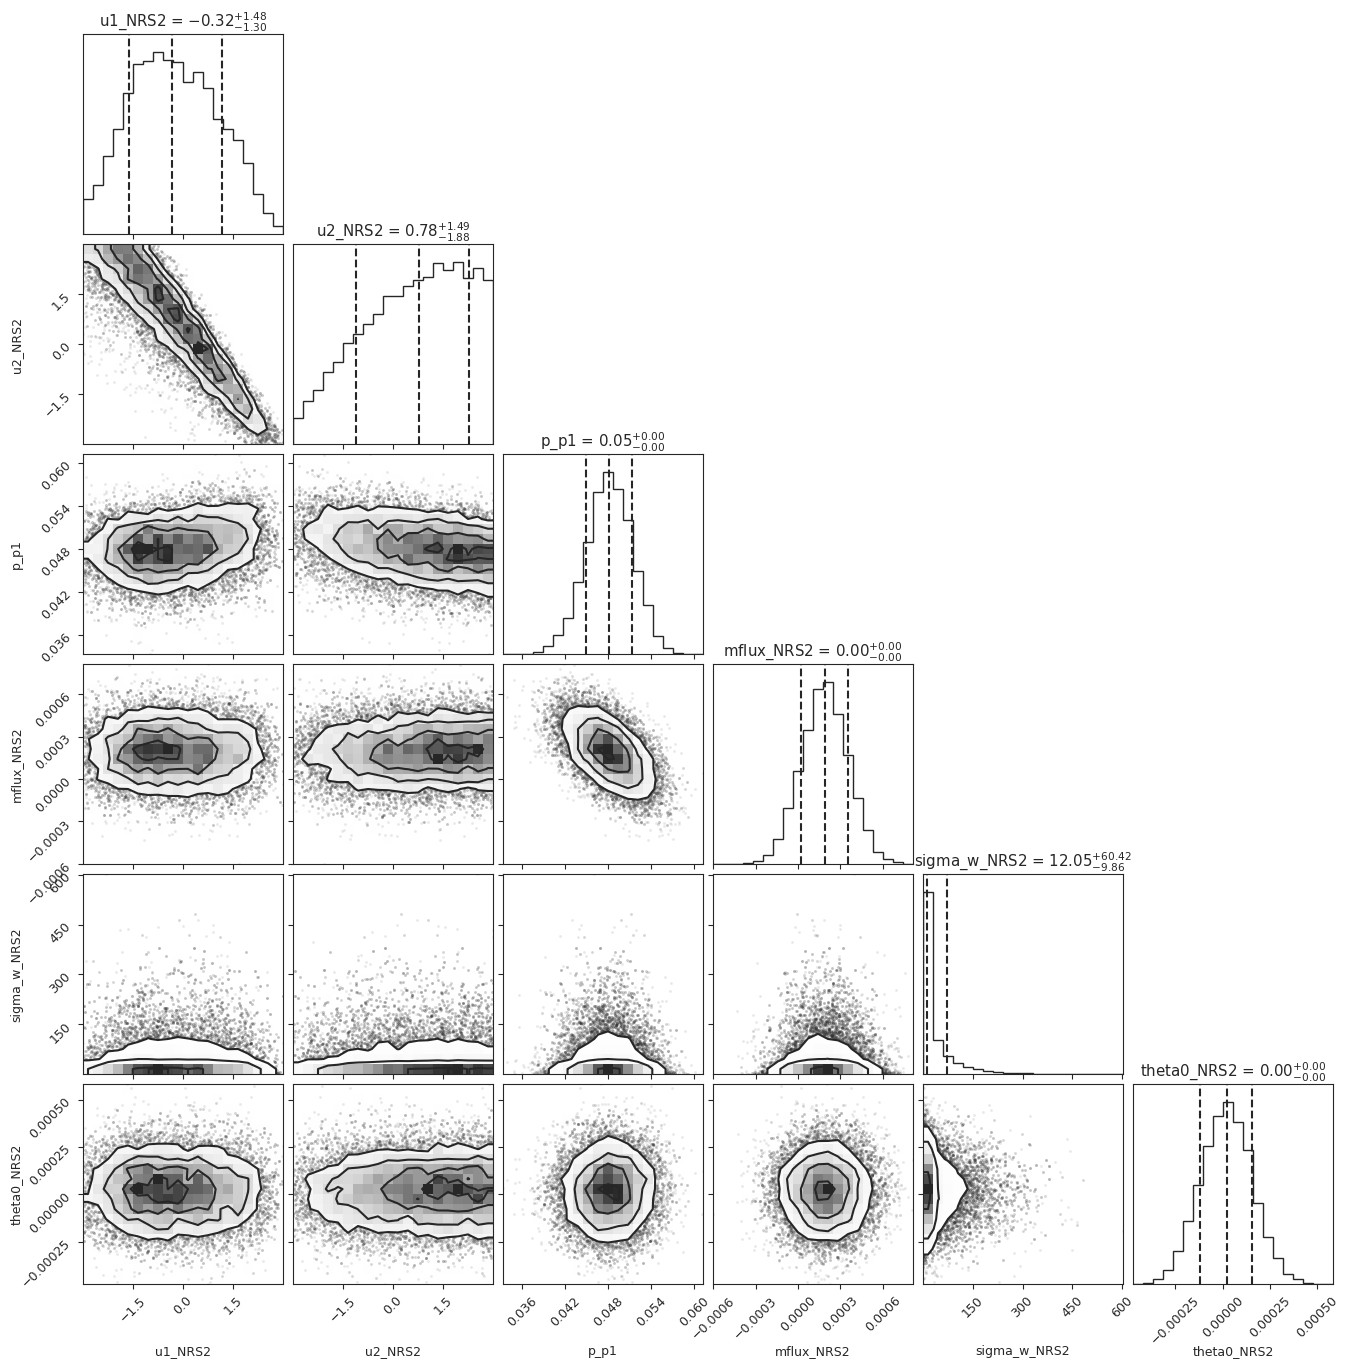

Log Evidence: 10641.581722908368


In [14]:
# Corner plot
list_post = []
names = []
for f in results.posteriors['posterior_samples']:
    if f not in ['unnamed', 'loglike']:
        names.append(f)
        list_post.append(results.posteriors['posterior_samples'][f])
tr = np.array(list_post).T
corner.corner(tr, labels = names, show_titles = True, quantiles = [0.16, 0.50, 0.84])
# plt.savefig('/home/peng/PycharmProjects/S26/'+pn+'_'+str(round(trial_wl, 7))+'_fit/'+str(round(trial_wl, 7))+'_corner.png')
plt.show()

print('Log Evidence:', results.posteriors['lnZ'])

In [15]:
# Get best fit value of p_p1 and convert to transit depth
td_list = (results.posteriors['posterior_samples']['p_p1']**2)

td = np.nanmedian(td_list)
tderr = np.sqrt(np.var(td_list))

print('Wavelength:', trial_wl, '\n',
      'Transit Depth:', td, '\n', 
      'Errors:', tderr)

Wavelength: 4.2149372 
 Transit Depth: 0.0023166557020080553 
 Errors: 0.0003105304934965096


In [1]:
# Run speclc_fit.py which loops through all indices of spec_lcs or any similar dict and fits each light curve
%run nirspec_speclc_fit.py

Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_2.6774409_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_2.684232_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_2.691023_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_2.6978137_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_2.7046042_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_2.7113945_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_2.7182198_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_2.7250332_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracti

32941it [03:31, 155.63it/s, batch: 3 | bound: 1 | nc: 1 | ncall: 693930 | eff(%):  4.595 | loglstar: 11424.923 < 11428.512 < 11425.364 | logz: 11406.290 +/-  0.116 | stop:  0.912]            
32860it [03:39, 149.90it/s, batch: 3 | bound: 1 | nc: 1 | ncall: 691838 | eff(%):  4.597 | loglstar: 11484.265 < 11487.842 < 11484.703 | logz: 11465.832 +/-  0.114 | stop:  0.908]            
32981it [03:38, 151.10it/s, batch: 3 | bound: 1 | nc: 1 | ncall: 694740 | eff(%):  4.595 | loglstar: 11461.515 < 11465.126 < 11462.003 | logz: 11442.933 +/-  0.115 | stop:  0.909]            
32995it [03:37, 151.71it/s, batch: 3 | bound: 1 | nc: 1 | ncall: 696279 | eff(%):  4.587 | loglstar: 11397.883 < 11401.516 < 11398.329 | logz: 11379.358 +/-  0.115 | stop:  0.899]            
32997it [03:42, 148.02it/s, batch: 3 | bound: 1 | nc: 1 | ncall: 694425 | eff(%):  4.599 | loglstar: 11390.331 < 11393.806 < 11390.737 | logz: 11371.673 +/-  0.115 | stop:  0.909]            
32848it [03:43, 146.73it/s, batch: 3 | b

In [15]:
# EMERGENCY - need to get the last 25 wavelengths into csv for nrs2 since too many wavelengths
# last_wl = [5.0094925, 5.0160629, 5.022606, 5.0291347, 5.0357019, 5.0422679, 5.0488328, 5.0553966, 5.0619461, 5.0684548, 5.0750152, 5.0815745, 5.0881326, 
#            5.0946895, 5.1012321, 5.1077339, 5.1142874, 5.1208397, 5.1273908, 5.1339407, 5.1404763, 5.147004, 5.1535503, 5.1600955, 5.1666395]

# with open(pn+'_'+itm+'.csv', 'w', newline = '') as outfile:
#     writer = csv.writer(outfile)
#     writer.writerow(['wavelength', 'transit depth', 'transit depth error', 'log evidence'])
#     for wvlngth in last_wl:
#         # Define data points 
#         t = t
#         f_s = bin_slc[wvlngth]['f']
#         ferr_s = bin_slc[wvlngth]['ferr']
    
#         params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_'+itm, 'u2_'+itm, 'ecc_p1', 'omega_p1', 'p_p1',
#                   'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
#                   'theta0_'+itm]
        
#         dists = ['fixed', 'fixed', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
#                  'fixed', 'normal', 'loguniform',
#                  'uniform']
        
#         hyperps = [per, t0, a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
#                    1.0, [0., 0.1], [1., 1000.], 
#                   [-10, 10]]
        
#         priors = juliet.generate_priors(params, dists, hyperps)
    
        
#         # Put data into dictionaries
#         times, fluxes, fluxes_err, linear_regressors, GP_regressors = {}, {}, {}, {}, {}
#         times[itm], fluxes[itm], fluxes_err[itm] = t, f_s, ferr_s
#         linear_regressors[itm] = regressors
#         GP_regressors[itm] = regressors
        
#         # Load dataset and run sampler
#         dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                          linear_regressors_lc = linear_regressors,
#                          ld_laws = 'quadratic', out_folder = pn+'_'+str(round(wvlngth, 7))+'_fit')
        
#         results = dataset.fit(sampler = 'dynamic_dynesty', nthreads = 3, verbose = True, n_live_points = 1000)

#         # Get transit depths
#         tds = (results.posteriors['posterior_samples']['p_p1']**2) * 100
    
#         # Write wavelength, median transit depth, transit depth error and log evidence into csv file
#         writer.writerow([wvlngth, np.nanmedian(tds), np.sqrt(np.var(tds)), results.posteriors['lnZ']])

Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_5.0094925_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_5.0160629_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_5.022606_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_5.0291347_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_5.0357019_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_5.0422679_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_5.0488328_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_5.0553966_fit/_dynesty_DNS_posteriors.pkl
Detected dynamic_dynesty sampler output files --- extract

# Transmission Spectrum

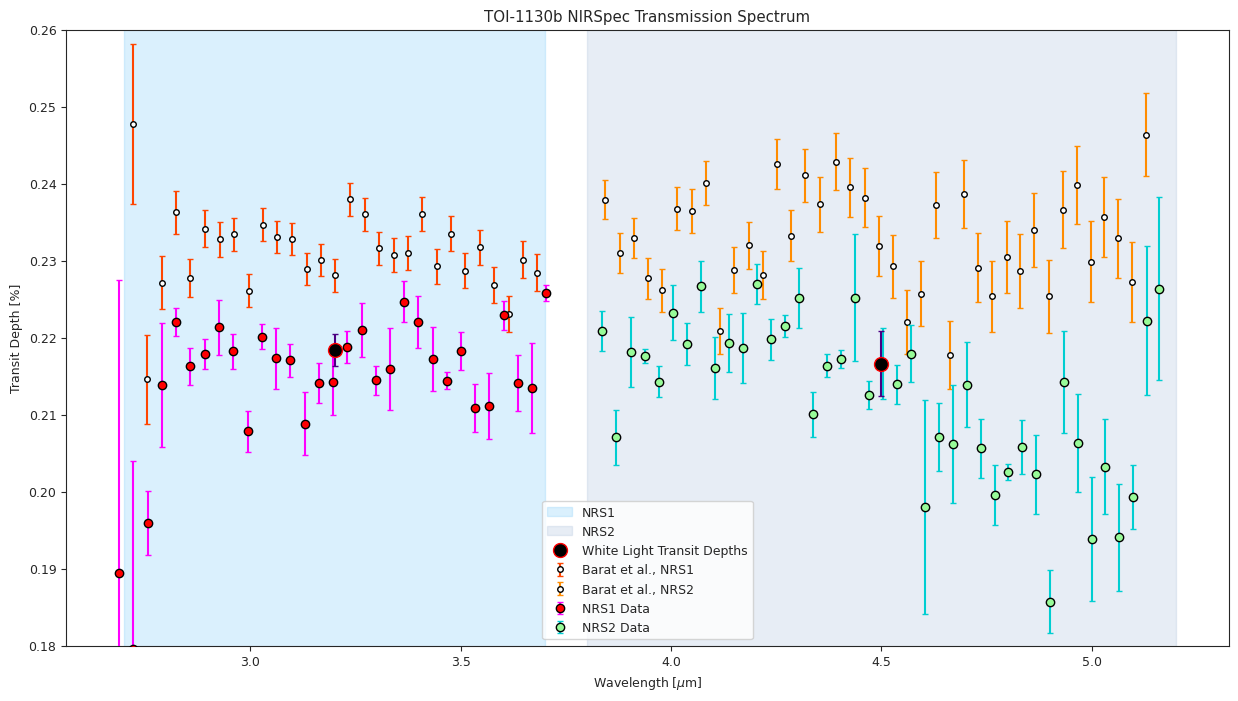

In [5]:
fig = plt.figure(figsize = (15, 8))

# Plot wavlength ranges for each detector
nrs1, nrs2 = [2.7, 3.7], [3.8, 5.2]
ys = [0.10, 0.40]   # Set ylim such that this spans the entire screen
plt.fill_betweenx(ys, nrs1[0], nrs1[1], color = 'lightskyblue', alpha = 0.3, zorder = 1, label = 'NRS1')
plt.fill_betweenx(ys, nrs2[0], nrs2[1], color = 'lightsteelblue', alpha = 0.3, zorder = 1, label = 'NRS2')

# Plot transit depths from white light curves
central_bins = [3.2, 4.5]
central_td = [0.2184226235891346, 0.2166471182659463]
central_tderr = [0.0021033446739131805, 0.004233196717110537]

plt.errorbar(central_bins, central_td, yerr = central_tderr, 
             fmt = 'o', capsize = 2, ms = 10, mfc = 'k', mec = 'r', color = 'indigo', label = 'White Light Transit Depths', zorder = 10)

# Plot spectrum from Barat et al., 2026 for comparison
barat_nrs1 = pd.read_csv('barat_toi1130b_spectrum_nrs1.csv')
barat_wl_nrs1 = barat_nrs1['CENTRALWAVELNG']
barat_td_nrs1 = barat_nrs1['PL_TRANDEP']
barat_tderr_nrs1 = barat_nrs1['PL_TRANDEPERR1']

barat_nrs2 = pd.read_csv('barat_toi1130b_spectrum_nrs2.csv')
barat_wl_nrs2 = barat_nrs2['CENTRALWAVELNG']
barat_td_nrs2 = barat_nrs2['PL_TRANDEP']
barat_tderr_nrs2 = barat_nrs2['PL_TRANDEPERR1']

plt.errorbar(barat_wl_nrs1, barat_td_nrs1, yerr = barat_tderr_nrs1, 
             fmt = 'o', capsize = 2, ms = 4, mfc = 'w', mec = 'k', color = 'orangered', label = 'Barat et al., NRS1', zorder = 1)
plt.errorbar(barat_wl_nrs2, barat_td_nrs2, yerr = barat_tderr_nrs2, 
             fmt = 'o', capsize = 2, ms = 4, mfc = 'w', mec = 'k', color = 'darkorange', label = 'Barat et al., NRS2', zorder = 1)


# NRS 1
nrs1_data = pd.read_csv('TOI-1130b_NRS1-Cluster.csv')
nrs1_wl = np.array(nrs1_data['wavelength'])
nrs1_td = np.array(nrs1_data['transit depth'])
nrs1_tderr = np.array(nrs1_data['transit depth error'])

nrs1_wl, nrs1_td, nrs1_tderr = juliet.bin_data(nrs1_wl, nrs1_td, 5)
plt.errorbar(nrs1_wl, nrs1_td, yerr = nrs1_tderr, 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'r', mec = 'k', color = 'fuchsia', label = 'NRS1 Data', zorder = 8)

# NRS 2
nrs2_data = pd.read_csv('TOI-1130b_NRS2-Cluster.csv')
nrs2_wl = np.array(nrs2_data['wavelength'])
nrs2_td = np.array(nrs2_data['transit depth'])
nrs2_tderr = np.array(nrs2_data['transit depth error'])

nrs2_wl, nrs2_td, nrs2_tderr = juliet.bin_data(nrs2_wl, nrs2_td, 5)
plt.errorbar(nrs2_wl, nrs2_td, yerr = nrs2_tderr, 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'palegreen', mec = 'k', color = 'darkturquoise', label = 'NRS2 Data', zorder = 8)


plt.title(pn+' NIRSpec Transmission Spectrum')
plt.xlabel('Wavelength [$\mu$m]')
plt.ylabel('Transit Depth [%]')
plt.ylim(0.18, 0.26)
plt.legend()
plt.show()